In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure, filters

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

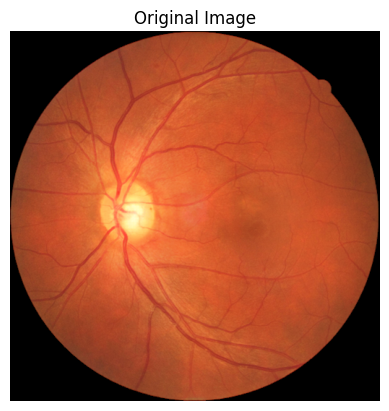

In [3]:
img = cv2.imread("/kaggle/input/datasets/amimulahasanrofik/abu-sayed/Fundus_CIMT_2903 Dataset/100464002_L.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

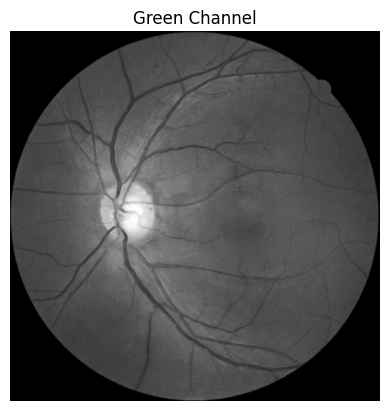

In [4]:
green = img[:, :, 1]

plt.imshow(green, cmap='gray')
plt.title("Green Channel")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

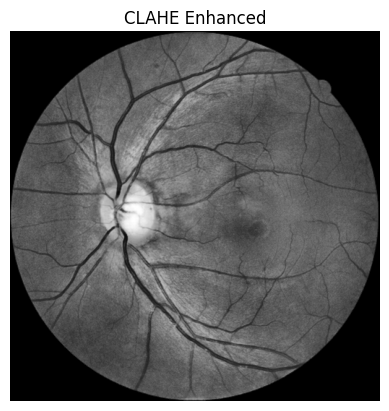

In [5]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
green_clahe = clahe.apply(green)

plt.imshow(green_clahe, cmap='gray')
plt.title("CLAHE Enhanced")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

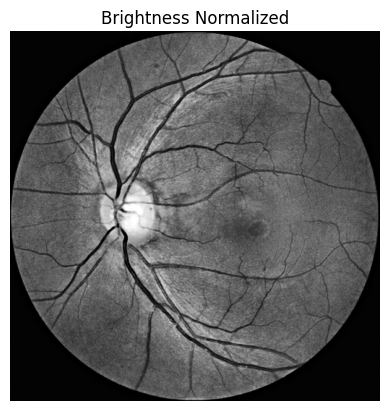

In [6]:
blur = cv2.GaussianBlur(green_clahe, (25,25), 0)
normalized = cv2.addWeighted(green_clahe, 1.5, blur, -0.5, 0)

plt.imshow(normalized, cmap='gray')
plt.title("Brightness Normalized")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

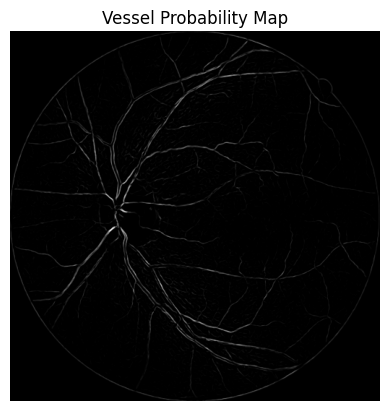

In [7]:
from skimage.filters import frangi

vessel = frangi(normalized)

plt.imshow(vessel, cmap='gray')
plt.title("Vessel Probability Map")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

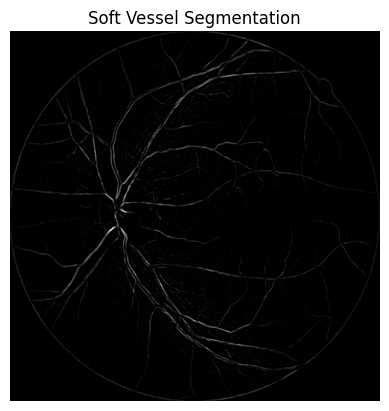

In [8]:
vessel_norm = (vessel - vessel.min()) / (vessel.max() - vessel.min())

plt.imshow(vessel_norm, cmap='gray')
plt.title("Soft Vessel Segmentation")
plt.axis('off')